### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../../data/synthetic/drvi_repro_cc_ext/simulated_data_cc_2.h5ad")

In [5]:
adata.X = adata.layers["counts"]

In [6]:
adata.X

array([[ 0,  1,  0, ...,  0,  0,  0],
       [ 0,  1,  0, ...,  0,  0, 10],
       [ 0, 38,  0, ...,  0,  0,  0],
       ...,
       [ 0,  3,  0, ...,  0,  0,  0],
       [ 0,  7,  0, ...,  0,  0,  0],
       [ 2,  5,  0, ..., 14,  0,  0]])

##### Is the matrix sparse?

### Sanity-Checking the Data

### Pre-processing

In [7]:
adata.var["gene_symbols"] = adata.var.index

In [8]:
adata.var["gene_symbols"]

26      26
661    661
419    419
499    499
427    427
      ... 
613    613
916    916
986    986
64      64
192    192
Name: gene_symbols, Length: 1000, dtype: object

In [9]:
genes_process_monotonic = adata.uns["affected_genes"]['0']
genes_process_sinusodial = adata.uns["affected_genes"]['1']

In [10]:
contained_genes_process_monotonic = adata.var["gene_symbols"].isin(adata.uns["affected_genes"]['0'])
contained_genes_process_sinusodial = adata.var["gene_symbols"].isin(adata.uns["affected_genes"]['1'])

In [11]:
process_monotonic_indices = np.where(contained_genes_process_monotonic)[0]
process_sinusodial_indices = np.where(contained_genes_process_sinusodial)[0]

all_known_indices = np.hstack((process_monotonic_indices)) # TODO - modify all_known indices based on experiment that is being run 
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((process_monotonic_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [12]:
rearranged_indices

array([ 14,  28,  29,  40,  51,  58,  59,  67,  73, 106, 119, 125, 128,
       147, 160, 166, 168, 174, 201, 215, 218, 228, 242, 252, 268, 274,
       282, 286, 310, 353, 356, 380, 395, 408, 424, 451, 461, 477, 480,
       482, 506, 507, 531, 532, 538, 545, 565, 596, 642, 643, 655, 666,
       670, 676, 691, 693, 700, 707, 711, 732, 751, 754, 772, 775, 792,
       793, 804, 813, 817, 829, 839, 842, 845, 847, 871, 884, 885, 900,
       914, 919, 920, 926, 946, 948, 956, 957, 978, 981, 996,   0,   1,
         2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  30,
        31,  32,  33,  34,  35,  36,  37,  38,  39,  41,  42,  43,  44,
        45,  46,  47,  48,  49,  50,  52,  53,  54,  55,  56,  57,  60,
        61,  62,  63,  64,  65,  66,  68,  69,  70,  71,  72,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 10

In [13]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_11180/3340023796.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj


### Pre-processing x2 - Calculating Gene Enrichment Scores

In [14]:
from anndata.utils import make_index_unique

# 1. Get the gene symbols and convert to a standard pandas Index
temp_index = pd.Index(adata.var['gene_symbols'].astype(str))

# 2. Use the anndata utility to make the index unique (appends -1, -2, etc. to duplicates)
adata.var_names = make_index_unique(temp_index)
adata.var_names.name = None

In [15]:
sc.tl.score_genes(
    adata,
    gene_list=genes_process_sinusodial,
    score_name="sinusodial_genes_enrichment_score"
)


sc.tl.score_genes(
    adata,
    gene_list=genes_process_monotonic,
    score_name="monotonic_genes_enrichment_score"
)

### Model Configuration

In [16]:
model_name = "e2, e10"

In [17]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 500 
config.epochs = 500

In [18]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [19]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [20]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [1]

In [21]:
# Creating Training Dataset
x = adata.X.astype(np.double)

In [22]:
# y holds the batch vector for the dataset
batch = (np.zeros((x.shape[0], 1)) * -1).astype(np.int64)
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 1000
dataset.in_dim = 1000
Dataset seed: 68715


In [23]:
adata.var["gene_symbols"]

95      95
290    290
591    591
434    434
147    147
      ... 
755    755
613    613
986    986
64      64
192    192
Name: gene_symbols, Length: 1000, dtype: object

In [24]:
# Creating (Disjoint) Masks
mask_sinusodial = np.zeros(adata.n_vars)
mask_sinusodial[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 0 

mask = torch.tensor([mask_sinusodial, mask_all])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_11180/1583264970.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_sinusodial, mask_all])


In [25]:
mask

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]], dtype=torch.float64)

In [26]:
adata.X.shape

(6000, 1000)

In [27]:
sinusodial_genes_potentially = adata.X[:,mask_sinusodial.astype(bool)]

In [28]:
sinusodial_genes_potentially

array([[  1,   1,   1, ...,  20,   3,  64],
       [  1,  15,   7, ...,  22,   1,  98],
       [ 38,  30,   1, ...,  17,  13,   5],
       ...,
       [  3,  14,  72, ...,  66,   2, 119],
       [  7,  11,   7, ...,   0,   3, 228],
       [  5,  62,   6, ...,  29,   3,  46]])

In [29]:
X = sinusodial_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

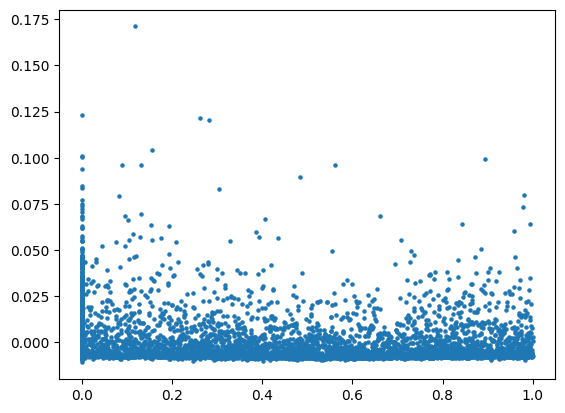

In [30]:
z = adata.obsm['ground_truth_z'][:,1]
plt.scatter(z, pc1, s=5)

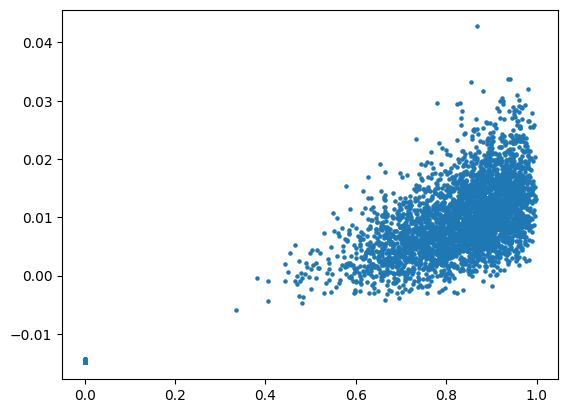

In [31]:
mask_monotonic = np.zeros(adata.n_vars)
mask_monotonic[adata.var["gene_symbols"].isin(genes_process_monotonic)] = 1
monotone_genes_potentially = adata.X[:,mask_monotonic.astype(bool)]

X = monotone_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

z = adata.obsm['ground_truth_z'][:,0]
plt.scatter(z, pc1, s=5)

In [36]:
adata

AnnData object with n_obs × n_vars = 6000 × 1000
    obs: 'pert', 'perfect_order', 'sinusodial_genes_enrichment_score', 'monotonic_genes_enrichment_score', 'batch'
    var: 'perfect_order', 'gene_symbols'
    uns: 'affected_genes', 'log1p', 'neighbors', 'pca', 'pert_colors', 'umap', 'new_gene_ordering'
    obsm: 'X_pca', 'X_umap', 'ground_truth_identity', 'ground_truth_z'
    varm: 'PCs', 'ground_truth_effect'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [34]:
adata.obsm['ground_truth_identity'].shape

(6000, 2)

In [35]:
adata.obsm['ground_truth_identity'][:,1]

array([1., 0., 1., ..., 1., 0., 0.])

In [37]:
adata.obsm['ground_truth_identity'].shape

(6000, 2)

In [38]:
adata.obsm['ground_truth_z']

array([[0.        , 0.25365049],
       [0.74341684, 0.        ],
       [0.87728848, 0.13594148],
       ...,
       [0.93108928, 0.5472905 ],
       [0.60824711, 0.        ],
       [0.        , 0.        ]])

In [39]:
adata.varm['ground_truth_effect']

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]])

### Configure Save Paths

In [40]:
epoch_embeddings_save_path = "/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_e2_e10"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

### Model Creation

In [41]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [42]:
torch.set_default_dtype(torch.float64)

In [43]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)


### Training

In [46]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)


trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

initialized early stopper
	TrainEpoch 0:	{'bce': -1047.948, 'kl': 2.736, 'elbo': -1050.685, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 1:	{'bce': -1047.255, 'kl': 2.79, 'elbo': -1050.045, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 2:	{'bce': -1047.112, 'kl': 2.867, 'elbo': -1049.979, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 3:	{'bce': -1047.013, 'kl': 2.836, 'elbo': -1049.849, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 4:	{'bce': -1046.833, 'kl': 2.891, 'elbo': -1049.724, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 5:	{'bce': -1046.556, 'kl': 2.896, 'elbo': -1049.452, 'll': 0.0, 'mi

### Saving Embeddings

In [49]:
embeddings_save_path = epoch_embeddings_save_path

In [50]:
checkpoint = torch.load(
    os.path.join(embeddings_save_path,  f"{model_name}_best_model.pt"),
    map_location=config.device
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

NBVAE(
  (components): ModuleList(
    (0): EuclideanComponent(R^2)
    (1): EuclideanComponent(R^10)
  )
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=128, out_features=1000, bias=True)
  (fc_sigma): Linear(in_features=128, out_features=1000, bias=True)
)

In [51]:
a = model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'), a[4].detach().to(torch.device("cpu")).numpy())

### Analysis

In [52]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [53]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

e2 2
e10 10


#### Visualization of Component 1 (R2)

In [54]:
adata.obs

,pert,perfect_order,sinusodial_genes_enrichment_score,monotonic_genes_enrichment_score,batch
3702,38,3702,25.890204,-18.584762,3702
3488,35,3488,0.001214,19.101419,3488
732,8,732,-7.218276,29.131185,732
5635,0,5635,22.463773,-15.981273,5635
4004,41,4004,36.175167,-25.830179,4004
...,...,...,...,...,...
5675,0,5675,22.306922,-16.345752,5675
1063,11,1063,-4.953957,25.653065,1063
1170,12,1170,-5.728294,27.455549,1170
3586,36,3586,-0.475106,15.245910,3586


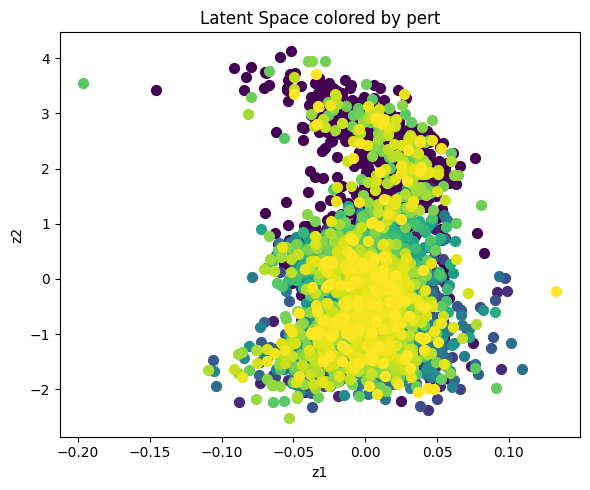

In [55]:
embeddings_key = "component1_e2"
desired_obs = 'pert'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = False
)

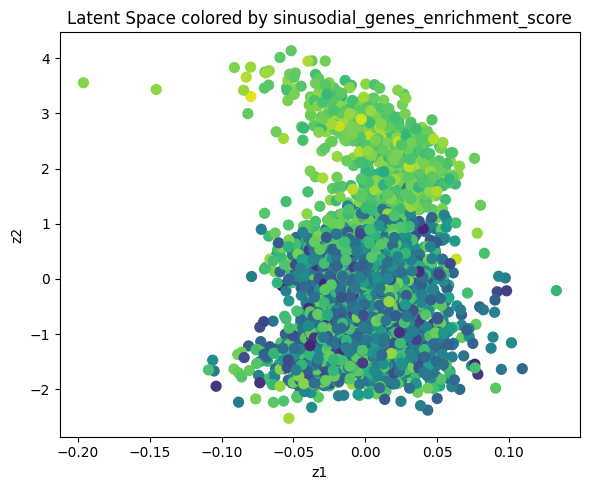

In [56]:
embeddings_key = "component1_e2"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = False
)         

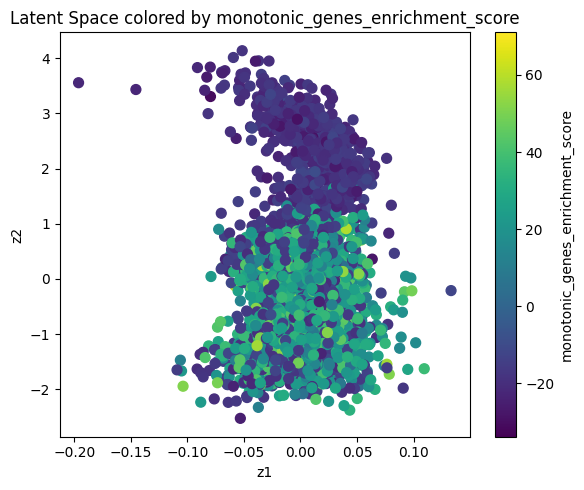

In [61]:
embeddings_key = "component1_e2"
desired_obs = 'monotonic_genes_enrichment_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation = desired_obs,
    show_legend = True
)         

Text(0.5, 1.0, 'Sinusodial Genes Enrichment Score Distribution')

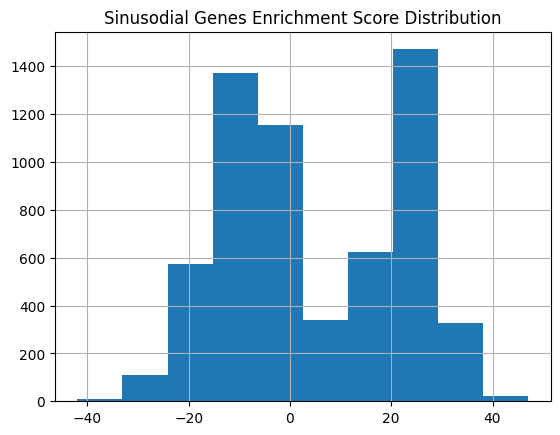

In [58]:
ax = adata.obs["sinusodial_genes_enrichment_score"].hist()
ax.set_title("Sinusodial Genes Enrichment Score Distribution")

#### Visualization of Component 2 (E2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


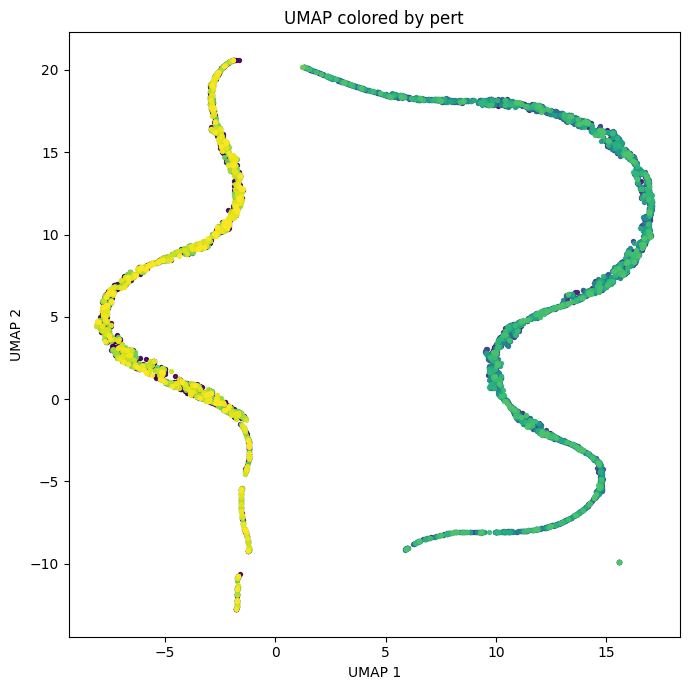

In [59]:
embeddings_key = "component2_e10"
desired_obs = 'pert'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


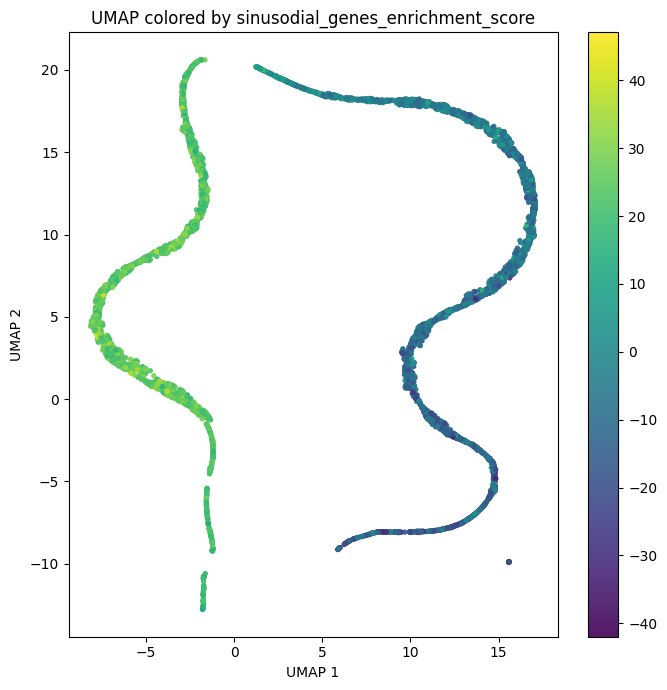

In [60]:
embeddings_key = "component2_e10"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)